In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = "/content/drive/MyDrive/UAS Praktikum Statistika dan Probabilitas/UAS Python.xlsx"
data = pd.read_excel(path)

In [ ]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4083,2,0,10614,3546,Medium
1,22253,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120366,3,1,36036,972,Medium
2,48883,HU-2011-1220,2011-01-01,2011-01-05,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",6612,4,0,2964,817,High
3,11731,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44865,3,5,-26055,482,High
4,22255,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",11367,5,1,3777,47,Medium


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [ ]:
# No 1: Rata-rata penjualan
rata_sales = data['Sales'].mean()
print(f"1. Rata-rata penjualan: {rata_sales}")

# No 2: Nilai statistik lainnya
print("\n2. Nilai Statistik Kolom Sales:")
print("   a. Penjualan Minimum:", data['Sales'].min())
print("   b. Penjualan Maksimum:", data['Sales'].max())
print("   c. Median Penjualan:", data['Sales'].median())
print("   d. Standar Deviasi Penjualan:", data['Sales'].std())
print("   e. Kuartil Pertama (Q1):", data['Sales'].quantile(0.25))
print("   f. Kuartil Ketiga (Q3):", data['Sales'].quantile(0.75))

1. Rata-rata penjualan: 623187.3383310587

2. Nilai Statistik Kolom Sales:
   a. Penjualan Minimum: 3
   b. Penjualan Maksimum: 190210816
   c. Median Penjualan: 12550.5
   d. Standar Deviasi Penjualan: 5462622.971860191
   e. Kuartil Pertama (Q1): 3092.0
   f. Kuartil Ketiga (Q3): 62197.25


In [ ]:
# No 3: Top 10 Order ID Terbesar
print("3. Top 10 Order ID dengan Penjualan Terbesar:")
top_10_besar = data.nlargest(10, 'Sales')[['Order ID', 'Sales']]
print(top_10_besar)

# No 4: Top 10 Order ID Terkecil
print("\n4. Top 10 Order ID dengan Penjualan Terkecil:")
top_10_kecil = data.nsmallest(10, 'Sales')[['Order ID', 'Sales']]
print(top_10_kecil)

3. Top 10 Order ID dengan Penjualan Terbesar:
             Order ID      Sales
16049  MX-2012-102848  190210816
8818   US-2011-152821  177067156
47451  MX-2014-133473  170314688
41994  MX-2014-139591  169276768
23752  MX-2013-169096  168590144
35263  MX-2014-127656  165596144
50782  MX-2014-166905  164925488
39215  MX-2014-127264  152346696
3048   MX-2011-136399  151628136
11333  MX-2012-147823  151628136

4. Top 10 Order ID dengan Penjualan Terkecil:
              Order ID  Sales
28811   CA-2013-111409      3
37365   US-2014-132031      3
17592   CA-2012-117611      5
14880     ZA-2012-3750      6
22966   CA-2013-129280      6
23568    IN-2013-22179      6
27461  ES-2013-2371724      6
28146     SA-2013-4930      6
28430   CA-2013-150007      6
34296   CA-2014-154718      6


In [ ]:
kolom_kategori = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Order Priority']

# No 5: Jumlah transaksi
print("5. JUMLAH TRANSAKSI BERDASARKAN KATEGORI:")
for kol in kolom_kategori:
    print(f"\n--- Berdasarkan {kol} ---")
    print(data[kol].value_counts())

# No 6: Total penjualan
print("\n6. TOTAL PENJUALAN BERDASARKAN KATEGORI:")
for kol in kolom_kategori:
    print(f"\n--- Total Sales Berdasarkan {kol} ---")
    print(data.groupby(kol)['Sales'].sum())

5. JUMLAH TRANSAKSI BERDASARKAN KATEGORI:

--- Berdasarkan Ship Mode ---
Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

--- Berdasarkan Segment ---
Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

--- Berdasarkan Region ---
Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

--- Berdasarkan Category ---
Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

--- Berdasarkan Sub-Category ---
Sub-Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones   

/tmp/ipykernel_5367/4182634035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_city, x='Sales', y='City', palette='viridis')


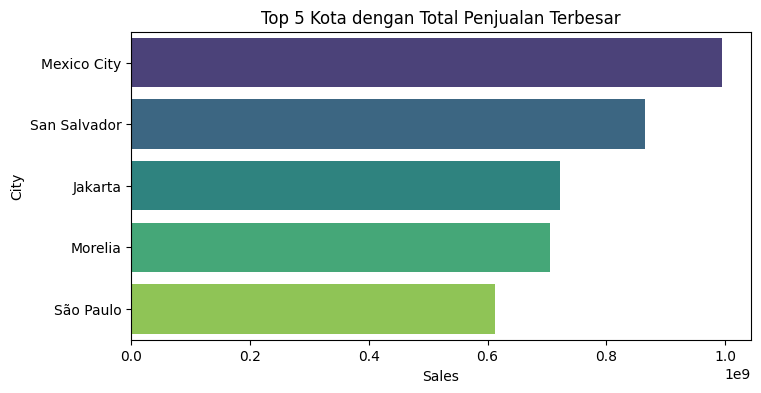

/tmp/ipykernel_5367/4182634035.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_state, x='Sales', y='State', palette='magma')


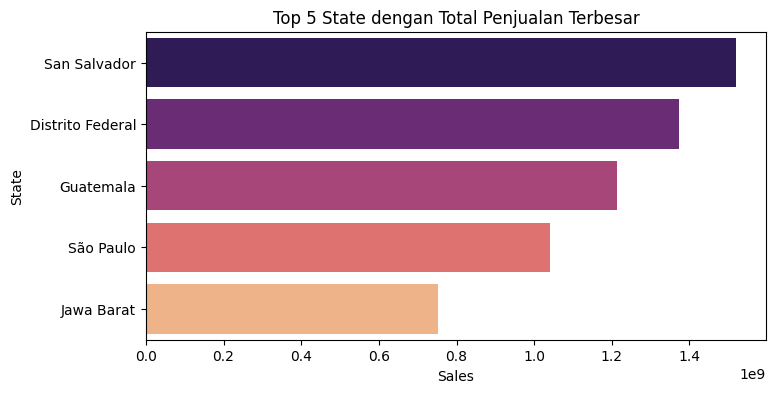

/tmp/ipykernel_5367/4182634035.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='coolwarm')


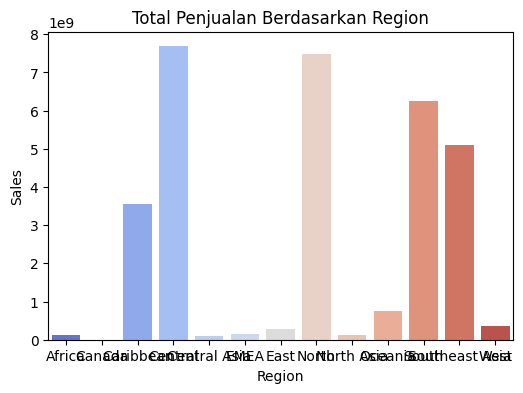

/tmp/ipykernel_5367/4182634035.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='crest')


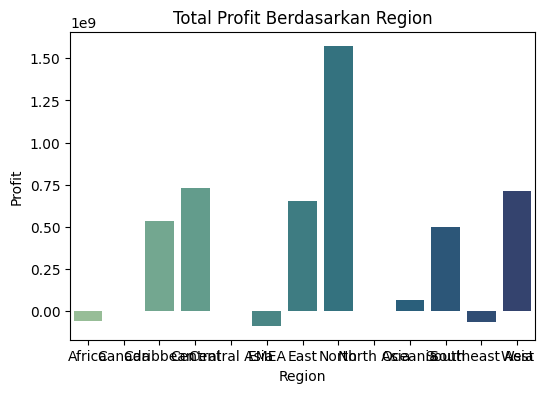

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 & 2. Top 5 Kota dengan Penjualan Terbesar
top_5_city = data.groupby('City')['Sales'].sum().nlargest(5).reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=top_5_city, x='Sales', y='City', palette='viridis')
plt.title('Top 5 Kota dengan Total Penjualan Terbesar')
plt.show()

# 3 & 4. Top 5 State/Provinsi dengan Penjualan Terbesar
top_5_state = data.groupby('State')['Sales'].sum().nlargest(5).reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=top_5_state, x='Sales', y='State', palette='magma')
plt.title('Top 5 State dengan Total Penjualan Terbesar')
plt.show()

# 5 & 6. Total Penjualan Berdasarkan Region
region_sales = data.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='coolwarm')
plt.title('Total Penjualan Berdasarkan Region')
plt.show()

# 7 & 8. Total Profit Berdasarkan Region
region_profit = data.groupby('Region')['Profit'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=region_profit, x='Region', y='Profit', palette='crest')
plt.title('Total Profit Berdasarkan Region')
plt.show()

/tmp/ipykernel_5367/414659771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='Category', y='Sales', palette='Set1')


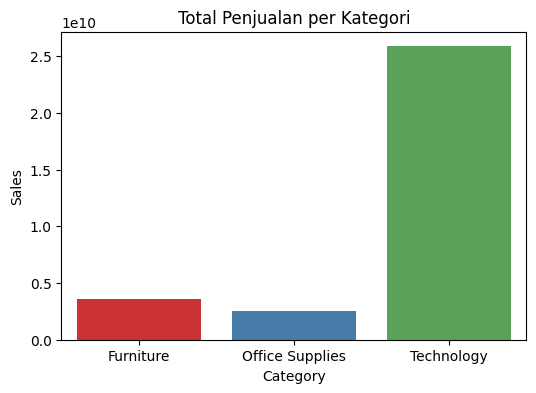

/tmp/ipykernel_5367/414659771.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_sales, x='Sales', y='Sub-Category', palette='Set2')


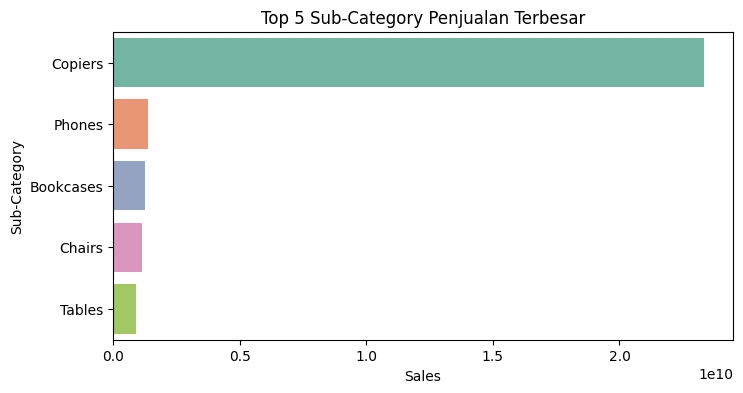

--- Rata-rata Penjualan per Category ---
Category
Furniture          3.628645e+05
Office Supplies    8.085146e+04
Technology         2.549173e+06
Name: Sales, dtype: float64

--- Total Quantity per Sub-Category ---
Sub-Category
Accessories    10946
Appliances      6078
Art            16301
Binders        21429
Bookcases       8310
Chairs         12336
Copiers         7454
Envelopes       8380
Fasteners       8390
Furnishings    11225
Labels          9322
Machines        4906
Paper          12822
Phones         11870
Storage        16917
Supplies        8543
Tables          3083
Name: Quantity, dtype: int64

--- Total Profit per Category ---
Category
Furniture          -183214363
Office Supplies     767291338
Technology         3991841618
Name: Profit, dtype: int64


In [ ]:
# 1 & 2. Total Penjualan berdasarkan Category
cat_sales = data.groupby('Category')['Sales'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=cat_sales, x='Category', y='Sales', palette='Set1')
plt.title('Total Penjualan per Kategori')
plt.show()

# 3 & 4. Top 5 Sub-Category dengan Penjualan Terbesar
sub_cat_sales = data.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=sub_cat_sales, x='Sales', y='Sub-Category', palette='Set2')
plt.title('Top 5 Sub-Category Penjualan Terbesar')
plt.show()

# 5 sampai 10. Angka Rata-rata, Quantity, dan Profit Produk
print("--- Rata-rata Penjualan per Category ---")
print(data.groupby('Category')['Sales'].mean())

print("\n--- Total Quantity per Sub-Category ---")
print(data.groupby('Sub-Category')['Quantity'].sum())

print("\n--- Total Profit per Category ---")
print(data.groupby('Category')['Profit'].sum())

/tmp/ipykernel_5367/2970304911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')


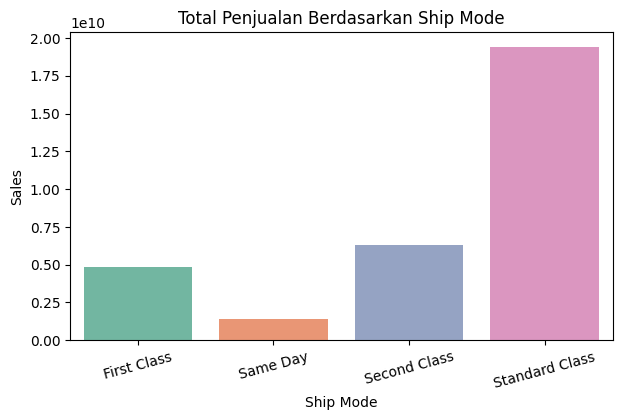

/tmp/ipykernel_5367/2970304911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')


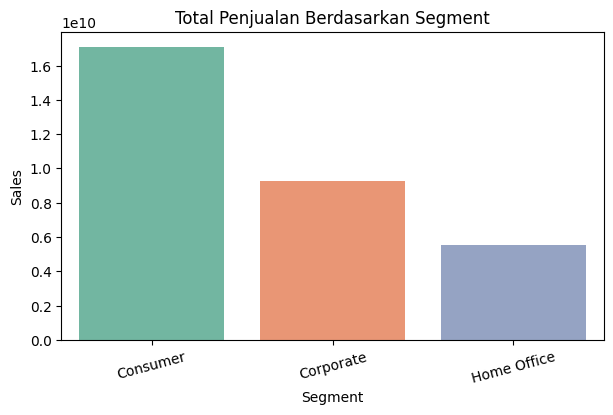

/tmp/ipykernel_5367/2970304911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')


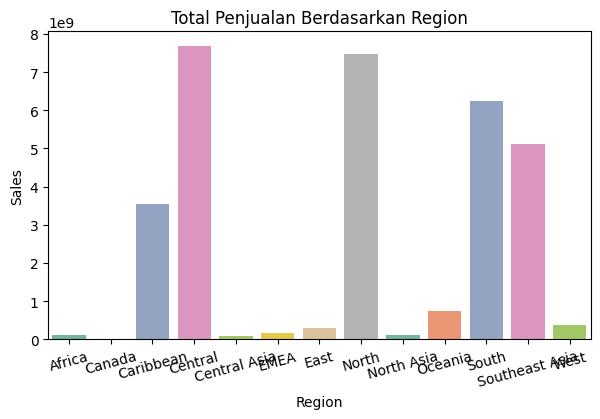

/tmp/ipykernel_5367/2970304911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')


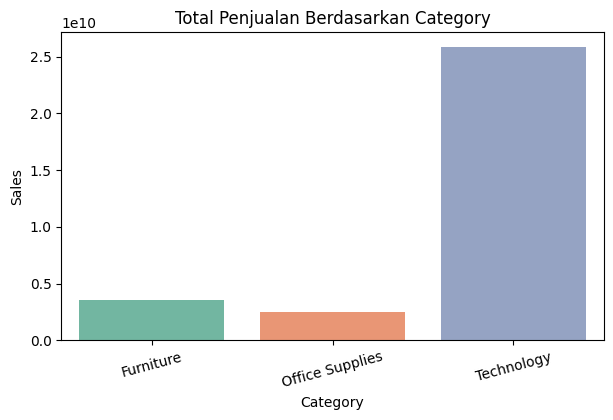

/tmp/ipykernel_5367/2970304911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')


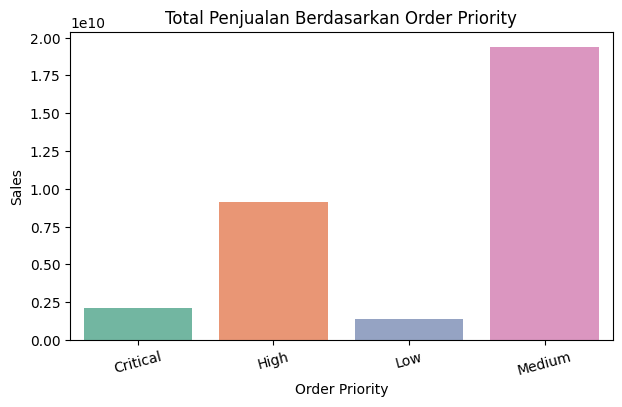

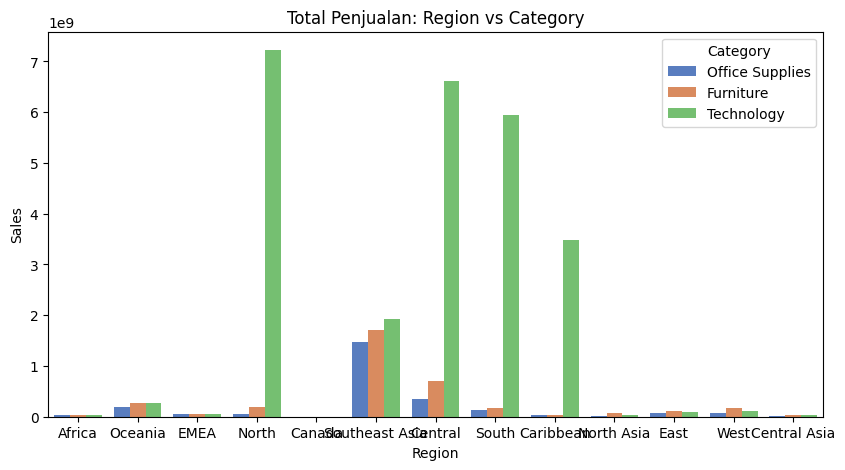

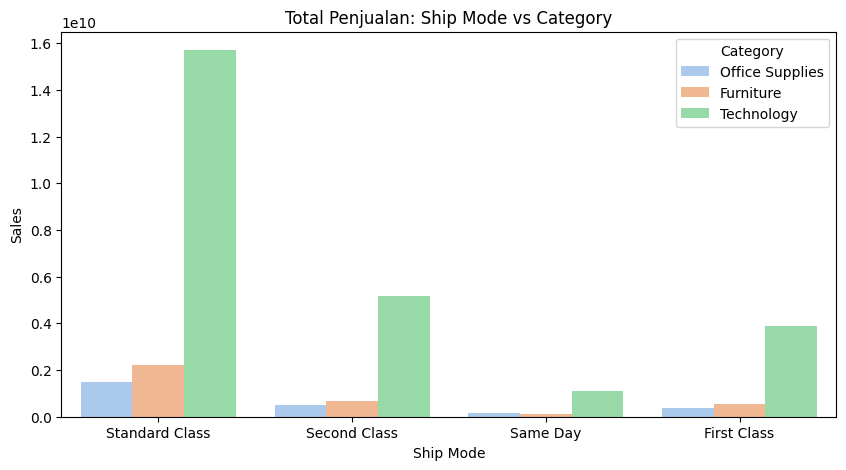

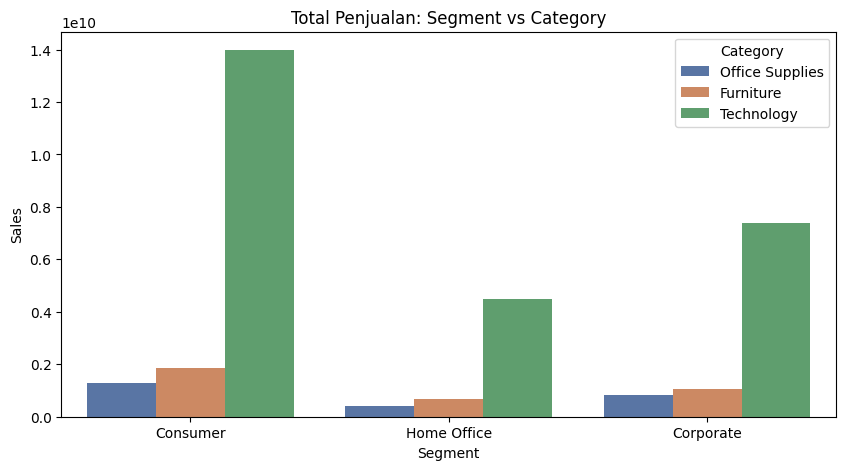

/tmp/ipykernel_5367/2970304911.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_priority, x='Order Priority', y='Profit', palette='Blues_r')


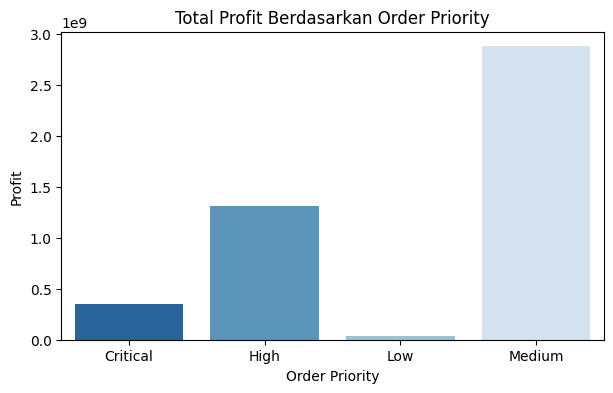

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 s.d 5: Visualisasi Tunggal Otomatis
kategori_tunggal = ['Ship Mode', 'Segment', 'Region', 'Category', 'Order Priority']
for ktg in kategori_tunggal:
    plt.figure(figsize=(7,4))
    sales_trend = data.groupby(ktg)['Sales'].sum().reset_index()
    sns.barplot(data=sales_trend, x=ktg, y='Sales', palette='Set2')
    plt.title(f'Total Penjualan Berdasarkan {ktg}')
    plt.xticks(rotation=15)
    plt.show()

# 6. Kombinasi Region dan Category
plt.figure(figsize=(10,5))
sns.barplot(data=data, x='Region', y='Sales', hue='Category', estimator=sum, errorbar=None, palette='muted')
plt.title('Total Penjualan: Region vs Category')
plt.show()

# 7. Kombinasi Ship Mode dan Category
plt.figure(figsize=(10,5))
sns.barplot(data=data, x='Ship Mode', y='Sales', hue='Category', estimator=sum, errorbar=None, palette='pastel')
plt.title('Total Penjualan: Ship Mode vs Category')
plt.show()

# 8. Kombinasi Segment dan Category
plt.figure(figsize=(10,5))
sns.barplot(data=data, x='Segment', y='Sales', hue='Category', estimator=sum, errorbar=None, palette='deep')
plt.title('Total Penjualan: Segment vs Category')
plt.show()

# 9. Total profit berdasarkan Order Priority
plt.figure(figsize=(7,4))
profit_priority = data.groupby('Order Priority')['Profit'].sum().reset_index()
sns.barplot(data=profit_priority, x='Order Priority', y='Profit', palette='Blues_r')
plt.title('Total Profit Berdasarkan Order Priority')
plt.show()